The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling t

1
2
3
4
5
6
7
8


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.99983406].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.99983406].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.99983406].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.99983406].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.99983406].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99983406..0.99983406].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got rang

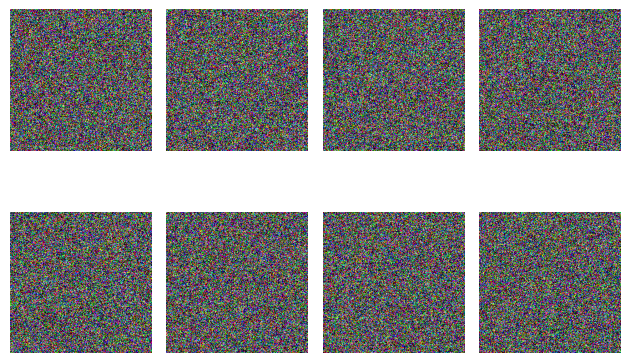

In [1]:
import torch
from matplotlib import pyplot as plt
import numpy as np
from monai_model import DDPMPL
from torchvision.transforms import transforms
from PIL import Image

hparams = {
    'lr': 1e-3,
    'weight_decay': 1e-5,
    'num_train_timesteps': 1000,
    'in_channels': 3,
    'out_channels': 3,
    'use_pre_trained': False
}
model = DDPMPL(**hparams)

device = torch.device("cuda")

# Generate a sample
state_dict = torch.load("/mnt/raid/home/ajarry/data/outputs_lightning/output_20250227_162118/model.ckpt")
model.load_state_dict(state_dict, strict=False)
model = model.to(device)

shape = (1, 3, 256,256)  # Adjust based on model's requirements

# List to store generated samples
samples = []

# Generate 8 samples
model.eval()
iter = 0
with torch.no_grad():
    for _ in range(8):
        iter+=1
        print(iter)
        # Generate a random sample
        noise = torch.randn(shape)
        noise = noise.to(device)
        sample = model(noise).cpu().squeeze()  # Generate image and move to CPU
        samples.append(sample)

# Plot the 8 samples in a 2x4 grid
fig, axes = plt.subplots(2, 4)
for i, ax in enumerate(axes.flat):
    # Transpose the sample to (H, W, C) and convert to numpy for plotting
    img = samples[i].numpy().transpose(1, 2, 0)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()